In [1]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import os
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
import importlib
import stft

In [2]:
argument = stft.StftArgument()
sft = stft.STFT(argument)

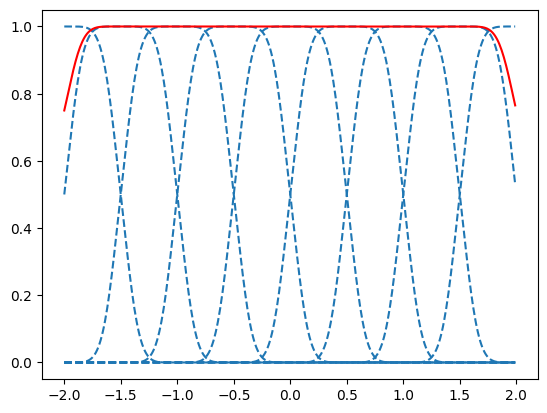

In [3]:
dx=0.01
lim = 2
xrange = np.arange(-lim,lim,dx)
ndiv = 2
irange = range(-int(ndiv*lim),int(ndiv*lim+1))
Ws = np.array([ [argument.stft_default_window(x-i/ndiv) for x in xrange] for i in irange])
for W in Ws:
    plt.plot(xrange, W, '--', color='tab:blue')
plt.plot(xrange, np.sum(Ws, axis=0)/ndiv, '-', color='red') 
plt.show()


In [4]:
importlib.reload(stft)

<module 'stft' from '/home/jakovac/Documents/Voice-recognition/stft.py'>

In [5]:
tmax = 1 #sec
nu = 201.8 #Hz
A = 1
trange = np.arange(0, tmax, sft.dt)
data = A*np.sin(2*np.pi*nu*trange)
sft.set_amplitude(data).transform()

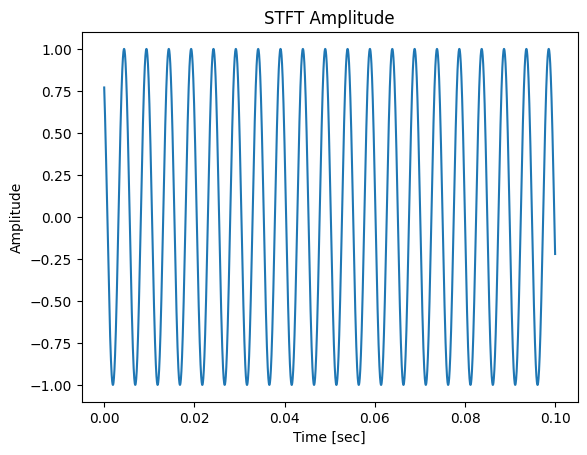

In [6]:
fig, ax =sft.plot_amplitude(0.2,0.3)
ax.set_title('STFT Amplitude')
ax.set_xlabel('Time [sec]')
ax.set_ylabel('Amplitude')
plt.show()

In [7]:
stft.play_sound(sft.amplitude, sample_rate=sft.sample_rate)

In [8]:
sft.window_times

array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
       0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 ])

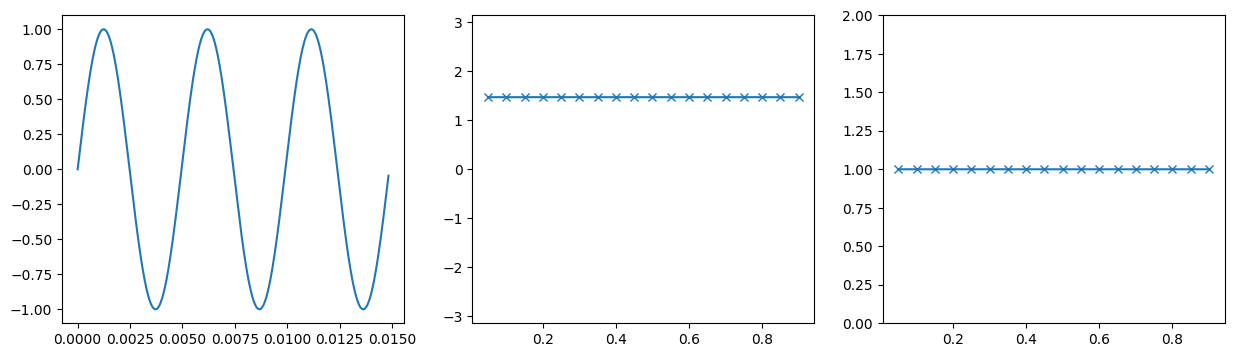

In [9]:
index = stft.find_maxima(stft.data_view(sft.fourier_data[0],'power'), interpolate=False)[0][0]
P = (stft.data_view(sft.fourier_data,'phases')[:,index]-2*np.pi*nu*sft.window_times)%np.pi-0.1
Q = stft.data_view(sft.fourier_data,'power')[:,index]
Q/=Q[0]
fig,ax=plt.subplots(ncols=3, figsize=(15,4))
Nmax = int(3/(nu*sft.dt))
ax[0].plot(trange[:Nmax], data[:Nmax])
ax[1].plot(sft.window_times, P,'x-')
ax[1].set_ylim(-np.pi,np.pi)
ax[2].plot(sft.window_times, Q,'x-')
ax[2].set_ylim(0,2)
plt.show()

In [10]:
nu_est = stft.find_maxima(stft.data_view(sft.fourier_data[0],'power'))[0][0]*(sft.frequencies[1]-sft.frequencies[0])
print(f"Estimated frequency: {nu_est:.1f} Hz")
print(f"Actual frequency: {nu:.1f} Hz")

Estimated frequency: 201.2 Hz
Actual frequency: 201.8 Hz


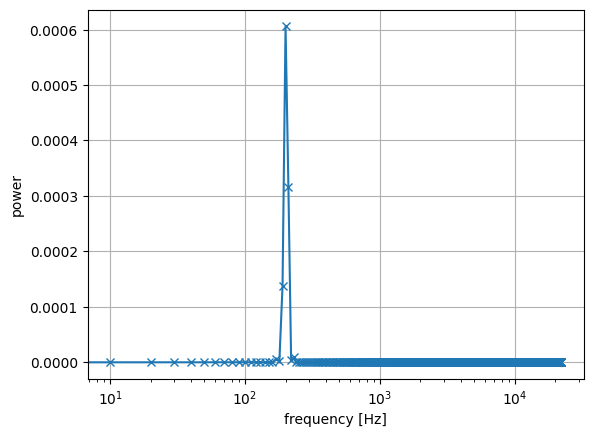

In [11]:
fig, ax = sft.plot_spectrum(0.5, 'x-', view='power')
ax.set_xlabel('frequency [Hz]')
ax.set_ylabel('power')
ax.grid(True)
plt.show()

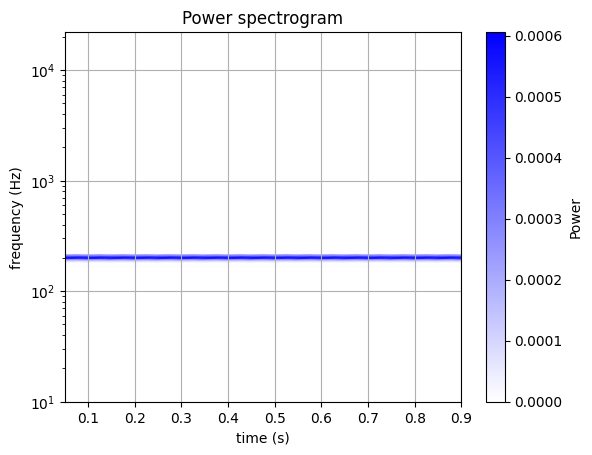

In [12]:
fig,ax,mesh = sft.plot_spectrogram( view='power')
ax.set_title('Power spectrogram')
ax.grid(True)
fig.colorbar(mesh, ax=ax, label='Power')
plt.show()

In [13]:
sft.invert()

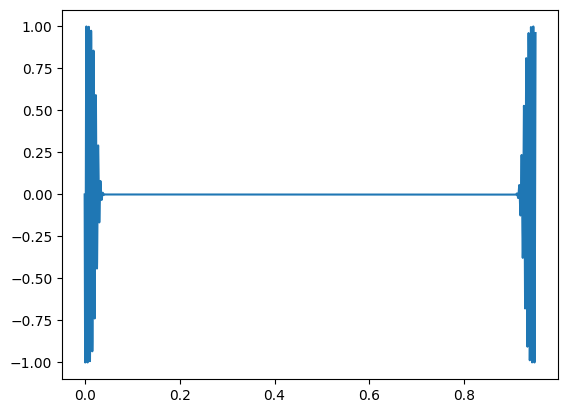

In [14]:
plt.plot(np.arange(len(sft.amplitude))*sft.dt, sft.amplitude - data[:len(sft.amplitude)])
plt.show()

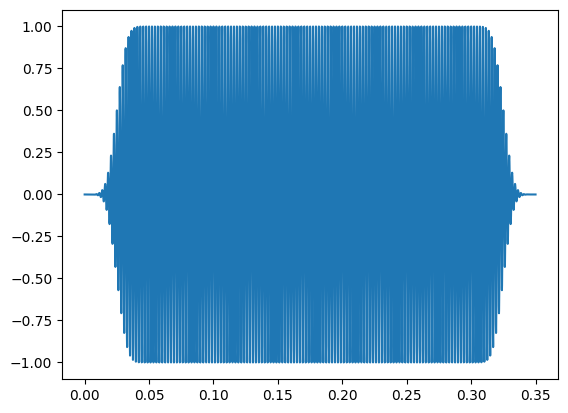

In [15]:
synth = stft.Synthesizer(stft.StftArgument(divide_step=1))
chord_list = [[[1.0,440]], [[1.0,440]], [[1.0,440]], [[1.0,440]], [[1.0,440]], [[1.0,440]]]
data_synth = synth.synthesize(chord_list)
plt.plot(np.arange(len(data_synth))*synth.dt, data_synth.real)
plt.show()

In [16]:
sft.fourier_data.shape, sft.frequencies.shape

((18, 2205), (2205,))

In [17]:
log_spectrogram, frequencies = stft.transform_to_logscale(sft)

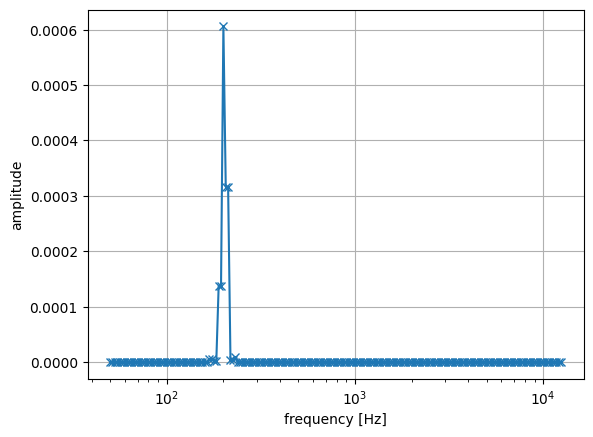

In [18]:
plt.plot(frequencies, np.abs(log_spectrogram[10])**2,'x-')
plt.xscale('log')
plt.xlabel('frequency [Hz]')
plt.ylabel('amplitude')
plt.grid(True)
plt.show()

In [28]:
freqs_expanded = np.broadcast_to(frequencies, log_spectrogram.shape)

result = np.stack([log_spectrogram.real, freqs_expanded], axis=-1)
result.shape

(18, 192, 2)

In [29]:
synthdata= synth.synthesize(result)

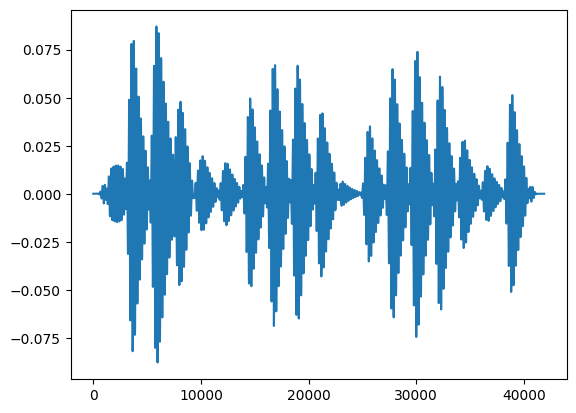

In [30]:
plt.plot(synthdata.real)

In [21]:
END HERE

SyntaxError: invalid syntax (3649074845.py, line 1)

In [ ]:
stft.play_sound(data_synth.real, sample_rate=synth.sample_rate)

phase difference: 3.14 rad


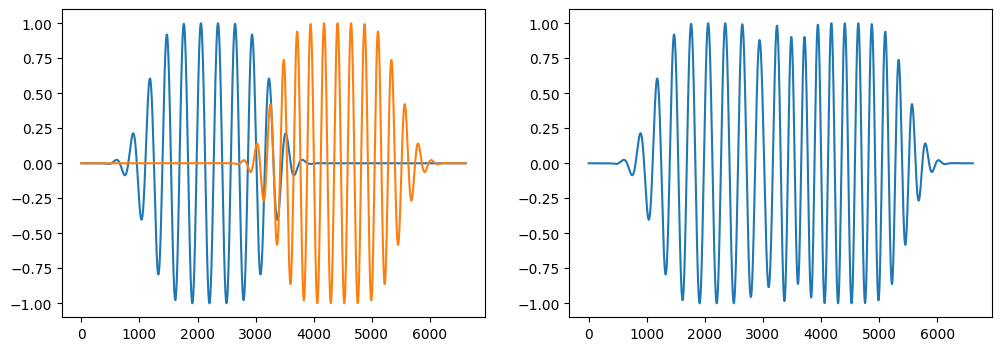

In [ ]:
nu1 = sft.frequencies[15]
nu2 = sft.frequencies[19]
trange = sft.dt*np.arange(0,2*sft.N_T)
wave1 = np.exp(2j*np.pi*nu1*trange)*sft.W_vector
wave2 = np.exp(2j*np.pi*nu2*trange)*sft.W_vector

data = wave1
tail = data[-sft.N_step:]
head = wave2[:sft.N_step]
phase_diff = np.angle(np.sum(tail*np.conj(head)))
print(f'phase difference: {phase_diff:.2f} rad')    
data = np.concatenate( ( data, np.zeros(sft.N_step, dtype=complex) ))
Nstart = len(data) - len(wave2)
add_data = np.concatenate( ( np.zeros(Nstart, dtype=complex), wave2*np.exp(1j*phase_diff) ))

fig, ax = plt.subplots(ncols=2, figsize=(12,4))

ax[0].plot(np.arange(len(data)), data.real, label=f'{nu1:.1f} Hz')
ax[0].plot(np.arange(len(data)), add_data.real, label=f'{nu2:.1f} Hz')
ax[1].plot(np.arange(len(data)), (data+add_data).real, label=f'{nu1:.1f} + {nu2:.1f} Hz')
plt.show()

Text(0.5, 0, 'phase difference [rad]')

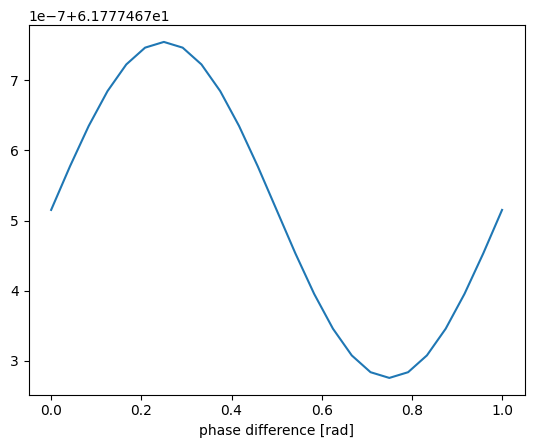

In [ ]:
nu1 = sft.frequencies[15]
nu2 = sft.frequencies[150]
trange = sft.dt*np.arange(0,2*sft.N_T)
wave1 = np.exp(2j*np.pi*nu1*trange)*sft.W_vector
wave2 = np.exp(2j*np.pi*nu2*trange)*sft.W_vector

data = wave1
data = np.concatenate( ( data, np.zeros(sft.N_step, dtype=complex) ))
Nstart = len(data) - len(wave2)
poslist = []
for rr in np.linspace(0, 1, 25):
    add_data = np.concatenate( ( np.zeros(Nstart, dtype=complex), wave2*np.exp(2j*np.pi*nu2*sft.dt*Nstart+2j*rr*np.pi) ))
    res = data+add_data
    poslist.append( [rr, np.linalg.norm(res)] )
poslist = np.array(poslist)
plt.plot(poslist[:,0], poslist[:,1])
plt.xlabel('phase difference [rad]')